# Week 12

# Recap ML models so far

In [126]:
import numpy as np
import pandas as pd
pd.options.mode.chained_assignment = None 

import pickle

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import r2_score

import statsmodels.api as sm

import xgboost as xgb

import os
from importlib import reload

import matplotlib.pyplot as plt
import matplotlib 
# import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')
from matplotlib.ticker import MultipleLocator

### example evaluation

In [127]:
df_comp_details = pd.read_csv('duopoly_competition_details.csv')
df_comp_details.fillna(0, inplace=True)

In [128]:

df_comp_details['selling_price'] = df_comp_details.apply(lambda r: r.price if r.demand>0 else np.nan, axis=1)

df_comp_details['revenue'] = df_comp_details['price'] * df_comp_details['demand']


df_comp_details.head(3)

,competition_id,selling_season,selling_period,competitor_id,price_competitor,price,demand,competitor_has_capacity,calculation_duration,errors,selling_price,revenue
0,34KdGK,1,1,SuperGoshawk,24.5,54.8,0,True,0.014,0.0,NaN,0.0
1,34KdGK,1,2,SuperGoshawk,27.0,54.8,0,True,0.013,0.0,NaN,0.0
2,34KdGK,1,3,SuperGoshawk,29.7,54.8,0,True,0.012,0.0,NaN,0.0


In [129]:
df_comp_details.groupby('competitor_id').agg({
    'competition_id' : 'nunique',
    'selling_season' : ['max', 'count'],
    'price_competitor' : 'mean',
    'price' : 'mean',
    'selling_price' : 'mean',
})

competition_id selling_season        price_competitor  \
                     nunique            max  count             mean   
competitor_id                                                         
DelicateMoose              4            100  40000        28.166010   
LoutishWorm                4            100  40000        58.344897   
SuperGoshawk               4            100  40000        43.770115   

                   price selling_price  
                    mean          mean  
competitor_id                           
DelicateMoose  33.173837     18.495041  
LoutishWorm    59.502513     31.176113  
SuperGoshawk   40.967525     31.601536

In [130]:
df_comp_details['unique_selling_season_key'] = df_comp_details.apply(lambda r:
                                "%s_%s" % (r.competition_id,r.selling_season), axis=1)

In [131]:
dfx_rev = df_comp_details.groupby('unique_selling_season_key').agg({
    'revenue' : 'sum'
}).reset_index()
dfx_rev.head()

,unique_selling_season_key,revenue
0,34KdGK_1,2375.1
1,34KdGK_10,2145.6
2,34KdGK_100,2309.4
3,34KdGK_11,2350.2
4,34KdGK_12,2356.8


array([[<Axes: title={'center': 'revenue'}>]], dtype=object)

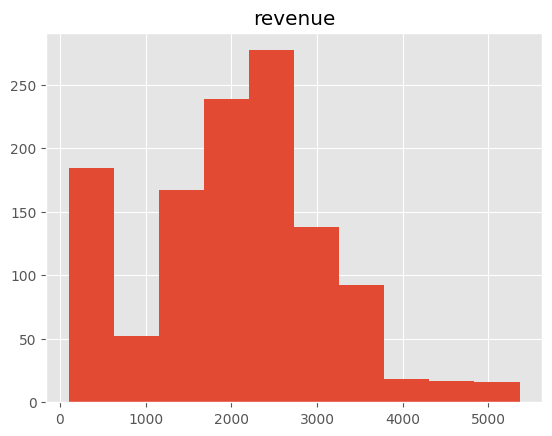

In [132]:
dfx_rev.hist()

In [133]:
dfp_util = pd.pivot_table(df_comp_details, 
                        values='demand', 
                        index=['selling_period'],
                        columns=['unique_selling_season_key'], 
                        aggfunc="mean")

# loop over columns to compute the % utilization
for c in dfp_util.columns:
    dfp_util[c] = dfp_util[c].cumsum()
    
dfp_util.tail()

unique_selling_season_key,34KdGK_1,34KdGK_10,34KdGK_100,34KdGK_11,34KdGK_12,34KdGK_13,34KdGK_14,34KdGK_15,34KdGK_16,34KdGK_17,...,wAS9Eo_90,wAS9Eo_91,wAS9Eo_92,wAS9Eo_93,wAS9Eo_94,wAS9Eo_95,wAS9Eo_96,wAS9Eo_97,wAS9Eo_98,wAS9Eo_99
selling_period,,,,,,,,,,,,,,,,,,,,,
96,78.0,78.0,73.0,75.0,74.0,80.0,77.0,77.0,80.0,76.0,...,80.0,75.0,65.0,78.0,80.0,80.0,75.0,80.0,79.0,73.0
97,78.0,78.0,74.0,77.0,75.0,80.0,77.0,77.0,80.0,79.0,...,80.0,75.0,65.0,78.0,80.0,80.0,77.0,80.0,80.0,73.0
98,78.0,78.0,74.0,78.0,76.0,80.0,77.0,77.0,80.0,80.0,...,80.0,75.0,65.0,78.0,80.0,80.0,78.0,80.0,80.0,73.0
99,79.0,78.0,76.0,78.0,78.0,80.0,77.0,77.0,80.0,80.0,...,80.0,75.0,65.0,78.0,80.0,80.0,80.0,80.0,80.0,73.0
100,80.0,78.0,77.0,79.0,80.0,80.0,77.0,77.0,80.0,80.0,...,80.0,75.0,65.0,78.0,80.0,80.0,80.0,80.0,80.0,73.0


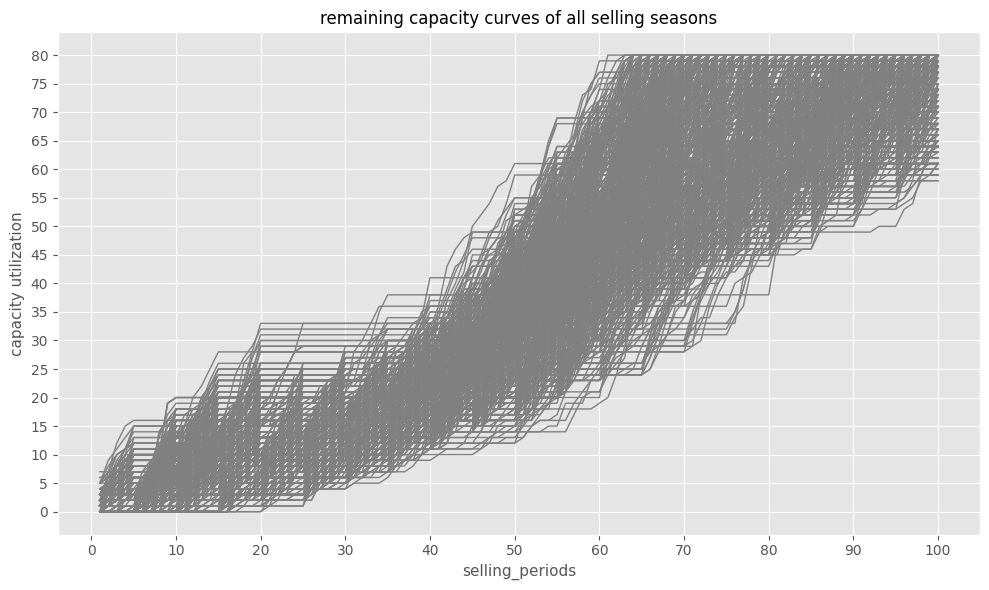

In [134]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(dfp_util.index, dfp_util, color='grey', 
        linestyle='-', linewidth=1, )
ax.set_xlabel('selling_periods', size=11)
# ax.set_xticks(np.arange(min(dft.index), max(dft.index)+1, 1.0))
ax.set_ylabel("capacity utilization" , size=11)

y_majorLocator = MultipleLocator(5)
ax.yaxis.set_major_locator(y_majorLocator)
x_majorLocator = MultipleLocator(10)
ax.xaxis.set_major_locator(x_majorLocator)

ax.set_title("remaining capacity curves of all selling seasons", size=12)
# ax.legend(loc=0)

ax.grid(True)
fig.tight_layout()

plt.show()

### joined stats per competition

In [135]:
dfx = df_comp_details.groupby(['competition_id','selling_season']).agg({
    'competitor_has_capacity' : 'sum',
    'demand' : 'sum',
    'price' : 'mean',
    'selling_price' : 'mean',
    'price_competitor' : 'mean',
    'revenue' : 'sum'
}).reset_index()

dfx['competitor_soldout'] = dfx.apply(lambda r: 0 if r.competitor_has_capacity==100 else 1, axis=1)
dfx['own_soldout'] = dfx.apply(lambda r: 1 if r.demand==80 else 0, axis=1)

dfx = dfx.groupby(['competition_id']).agg({
    'competitor_soldout' : 'mean',
    'own_soldout' : 'mean',
    'demand' : 'mean',
    'price' : 'mean',
    'selling_price' : 'mean',
    'price_competitor' : 'mean',
    'revenue' : 'mean'
}).round(2).reset_index()

dfx.sort_values('own_soldout', ascending=False)

,competition_id,competitor_soldout,own_soldout,demand,price,selling_price,price_competitor,revenue
10,mVcyye,1.00,0.97,79.69,8.90,2.34,7.42,185.04
3,3hXao2,0.00,0.77,78.03,42.99,18.86,59.17,1443.52
2,3UytKn,1.00,0.76,77.85,15.22,5.72,11.76,439.54
8,6JkS3i,1.00,0.75,77.75,66.21,45.07,56.44,3397.56
0,34KdGK,0.04,0.70,78.31,34.91,26.34,38.47,2048.10
9,NV8eT5,0.29,0.64,78.42,49.92,39.32,51.97,3057.49
11,wAS9Eo,0.05,0.63,78.04,36.84,26.70,40.05,2061.85
7,4WWGCn,0.09,0.56,77.27,42.20,32.48,44.60,2477.11
1,34ZK8D,0.00,0.46,75.10,57.73,29.20,55.87,2171.59
5,48G2zb,1.00,0.44,73.79,42.36,22.44,37.04,1671.48


### try to group competitions for similar demand model

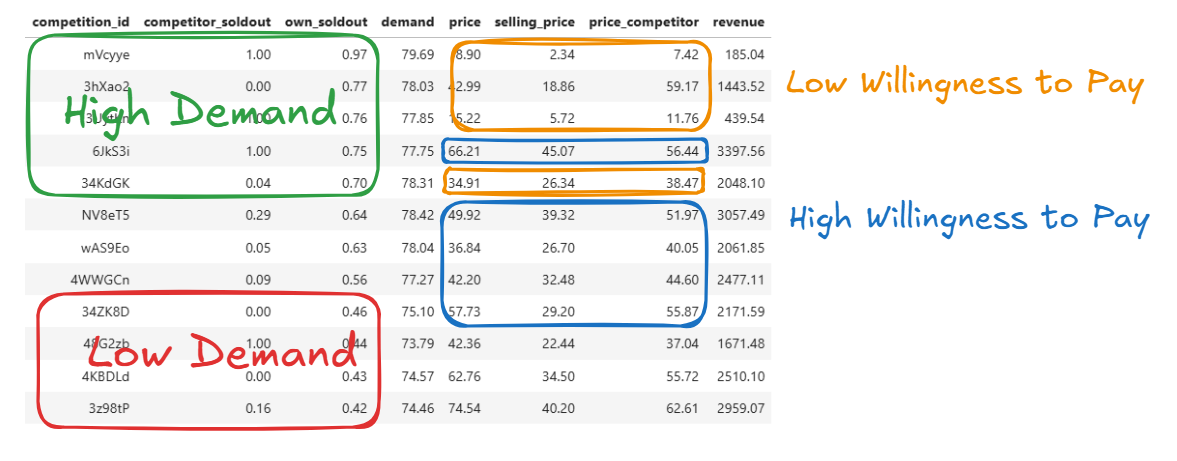

# (1) Capacity Utilization Curves

In [136]:
top_selling_seasons = dfx_rev[dfx_rev.revenue>=dfx_rev.revenue.quantile(0.9)].unique_selling_season_key.unique()
top_selling_seasons[:10]

array(['3z98tP_100', '3z98tP_16', '3z98tP_17', '3z98tP_26', '3z98tP_31',
       '3z98tP_32', '3z98tP_33', '3z98tP_38', '3z98tP_39', '3z98tP_4'],
      dtype=object)

In [137]:
dfp_top_curves = dfp_util[top_selling_seasons]
dfp_top_curves.shape

(100, 120)

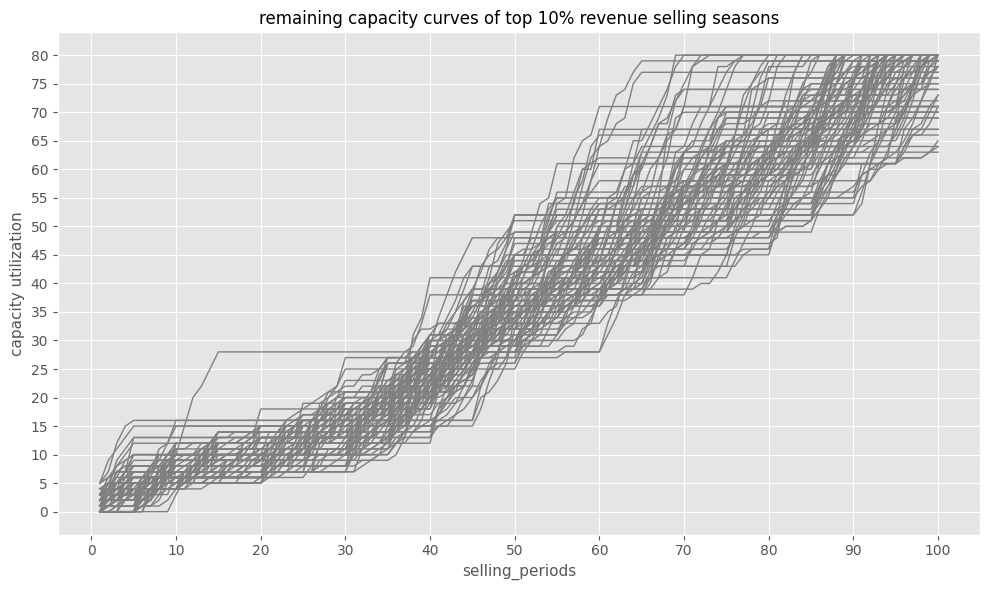

In [138]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(dfp_top_curves.index, dfp_top_curves, color='grey', 
        linestyle='-', linewidth=1, )
ax.set_xlabel('selling_periods', size=11)
# ax.set_xticks(np.arange(min(dft.index), max(dft.index)+1, 1.0))
ax.set_ylabel("capacity utilization" , size=11)

y_majorLocator = MultipleLocator(5)
ax.yaxis.set_major_locator(y_majorLocator)
x_majorLocator = MultipleLocator(10)
ax.xaxis.set_major_locator(x_majorLocator)

ax.set_title("remaining capacity curves of top 10% revenue selling seasons", size=12)
# ax.legend(loc=0)

ax.grid(True)
fig.tight_layout()

plt.show()

C:\Users\yannl\AppData\Local\Temp\ipykernel_32260\2725060798.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfp_top_curves['mean_curve'] = dfp_top_curves.values.mean(axis=1)


<Axes: xlabel='selling_period'>

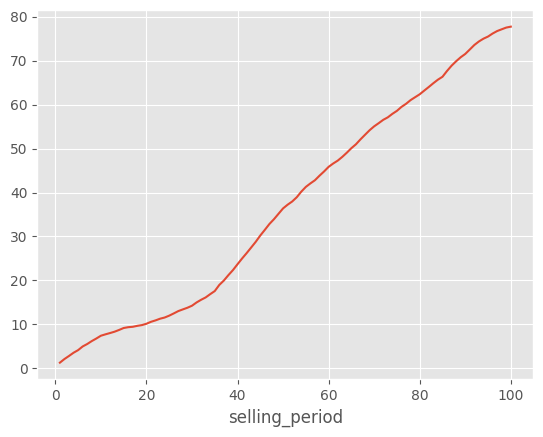

In [139]:
dfp_top_curves['mean_curve'] = dfp_top_curves.values.mean(axis=1)
dfp_top_curves['mean_curve'].plot()

In [140]:
target_sales_curve = {}
for t in np.arange(1,101,4):
    target = {}
    target['target_cap_util'] = round(dfp_top_curves.loc[t,'mean_curve']/80,2)
    target['target_sold_seats'] = round(dfp_top_curves.loc[t,'mean_curve'])
    target_sales_curve[str(t)] = target
    
target_sales_curve

{'1': {'target_cap_util': np.float64(0.02), 'target_sold_seats': 1},
 '5': {'target_cap_util': np.float64(0.05), 'target_sold_seats': 4},
 '9': {'target_cap_util': np.float64(0.08), 'target_sold_seats': 7},
 '13': {'target_cap_util': np.float64(0.1), 'target_sold_seats': 8},
 '17': {'target_cap_util': np.float64(0.12), 'target_sold_seats': 9},
 '21': {'target_cap_util': np.float64(0.13), 'target_sold_seats': 11},
 '25': {'target_cap_util': np.float64(0.15), 'target_sold_seats': 12},
 '29': {'target_cap_util': np.float64(0.17), 'target_sold_seats': 14},
 '33': {'target_cap_util': np.float64(0.2), 'target_sold_seats': 16},
 '37': {'target_cap_util': np.float64(0.25), 'target_sold_seats': 20},
 '41': {'target_cap_util': np.float64(0.31), 'target_sold_seats': 25},
 '45': {'target_cap_util': np.float64(0.38), 'target_sold_seats': 30},
 '49': {'target_cap_util': np.float64(0.44), 'target_sold_seats': 35},
 '53': {'target_cap_util': np.float64(0.49), 'target_sold_seats': 39},
 '57': {'target_

In [141]:
# save to pickle
with open('target_sales_curve.pkl', "wb") as f:
    pickle.dump(target_sales_curve, f, protocol=pickle.HIGHEST_PROTOCOL)

In [142]:
# load from pickle
with open('target_sales_curve.pkl', 'rb') as f:
            target_curve = pickle.load(f)
target_curve

{'1': {'target_cap_util': np.float64(0.02), 'target_sold_seats': 1},
 '5': {'target_cap_util': np.float64(0.05), 'target_sold_seats': 4},
 '9': {'target_cap_util': np.float64(0.08), 'target_sold_seats': 7},
 '13': {'target_cap_util': np.float64(0.1), 'target_sold_seats': 8},
 '17': {'target_cap_util': np.float64(0.12), 'target_sold_seats': 9},
 '21': {'target_cap_util': np.float64(0.13), 'target_sold_seats': 11},
 '25': {'target_cap_util': np.float64(0.15), 'target_sold_seats': 12},
 '29': {'target_cap_util': np.float64(0.17), 'target_sold_seats': 14},
 '33': {'target_cap_util': np.float64(0.2), 'target_sold_seats': 16},
 '37': {'target_cap_util': np.float64(0.25), 'target_sold_seats': 20},
 '41': {'target_cap_util': np.float64(0.31), 'target_sold_seats': 25},
 '45': {'target_cap_util': np.float64(0.38), 'target_sold_seats': 30},
 '49': {'target_cap_util': np.float64(0.44), 'target_sold_seats': 35},
 '53': {'target_cap_util': np.float64(0.49), 'target_sold_seats': 39},
 '57': {'target_

### Be smart and creative on how to adjust the price based on delta in observed sales versus target sales.

# -----
# (2) Linear regression to model demand

### X = [price, price_competitor]
### y = [demand]

### select meaningful training set
### split also in training and test set with a 80:20 ratio

In [143]:
dfx = df_comp_details.groupby(['competition_id','unique_selling_season_key']).agg({
    'demand' : 'sum',
    'competitor_has_capacity' : 'sum',
}).reset_index()

dfx['own_soldout'] = dfx.apply(lambda r: 1 if r.demand==80 else 0, axis=1)

interesting_competitions = dfx[dfx.own_soldout>0.66].competition_id.unique()
interesting_competitions

array(['34KdGK', '34ZK8D', '3UytKn', '3hXao2', '3z98tP', '48G2zb',
       '4KBDLd', '4WWGCn', '6JkS3i', 'NV8eT5', 'mVcyye', 'wAS9Eo'],
      dtype=object)

In [144]:
# filter for interesting competitions
df_select = df_comp_details[df_comp_details.competition_id.isin(interesting_competitions)]


#### filter out situations when we are soldout or competitor is sold out

In [145]:
df_select['demand_cumsum'] = df_select.groupby('unique_selling_season_key')['demand'].cumsum()

df_select = df_select[df_select.demand_cumsum<80]
df_select = df_select[df_select.competitor_has_capacity==True]

df_select.head()

,competition_id,selling_season,selling_period,competitor_id,price_competitor,price,demand,competitor_has_capacity,calculation_duration,errors,selling_price,revenue,unique_selling_season_key,demand_cumsum
0,34KdGK,1,1,SuperGoshawk,24.5,54.8,0,True,0.014,0.0,NaN,0.0,34KdGK_1,0
1,34KdGK,1,2,SuperGoshawk,27.0,54.8,0,True,0.013,0.0,NaN,0.0,34KdGK_1,0
2,34KdGK,1,3,SuperGoshawk,29.7,54.8,0,True,0.012,0.0,NaN,0.0,34KdGK_1,0
3,34KdGK,1,4,SuperGoshawk,32.7,54.8,0,True,0.010,0.0,NaN,0.0,34KdGK_1,0
4,34KdGK,1,5,SuperGoshawk,35.9,54.8,0,True,0.008,0.0,NaN,0.0,34KdGK_1,0


In [146]:
df_select.shape

(96347, 14)

In [147]:
# filter only on conditions when demand >0, so we sold something
# df_select = df_select[df_select.demand>0]

#### filter only on the interesting columns: [ 'price', 'demand' ]

In [148]:
df_select[['price', 'price_competitor', 'demand' ]].head(3)

,price,price_competitor,demand
0,54.8,24.5,0
1,54.8,27.0,0
2,54.8,29.7,0


#### split into random train & test set (80:20), using from sklearn.model_selection import train_test_split

In [149]:
trainseasons_80, testseasons_20 = train_test_split(df_select.unique_selling_season_key.unique(), test_size=0.2, random_state=42)

df_train = df_select[df_select.unique_selling_season_key.isin(trainseasons_80)]
df_test = df_select[df_select.unique_selling_season_key.isin(testseasons_20)]

In [150]:
df_train.shape

(76886, 14)

In [151]:
df_test.shape

(19461, 14)

In [152]:
y = df_train[['demand']]
X = df_train[[ 'price',  'price_competitor']]

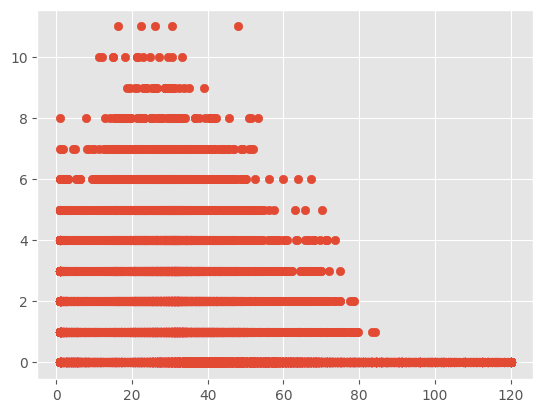

In [153]:
plt.scatter(X.price, y.demand)
plt.show()

In [154]:
X['intercept'] = 1

mod = sm.OLS(df_train.demand, X)
# mod = sm.regression.quantile_regression.QuantReg(y,X)

res = mod.fit()

print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 demand   R-squared:                       0.151
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     6842.
Date:                Tue, 13 Jan 2026   Prob (F-statistic):               0.00
Time:                        16:46:18   Log-Likelihood:            -1.2696e+05
No. Observations:               76886   AIC:                         2.539e+05
Df Residuals:                   76883   BIC:                         2.540e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
price               -0.0245      0.000  

In [155]:
res.params

price              -0.024481
price_competitor    0.013574
intercept           1.321025
dtype: float64

#### build a function to predict demand, given price

In [156]:
def est_demand(price, comp_price, para = res.params):
    demand = mod.predict(para, [price, comp_price, 1])
    demand = max(0,demand)
    return round(demand,1)


In [157]:
est_demand(60,50)

np.float64(0.5)

#### compute the estimated demand on the test dataframe

In [158]:
df_test['est_demand'] = df_test.apply(lambda r: est_demand(r.price, r.price_competitor), axis=1)

df_test[['price','price_competitor','demand','est_demand']].head()

,price,price_competitor,demand,est_demand
1000,47.8,23.0,0,0.5
1001,47.8,25.3,0,0.5
1002,47.8,27.8,0,0.5
1003,47.8,30.6,0,0.6
1004,47.8,33.7,0,0.6


#### compute and show some error metrics to measure the accuracy

In [159]:
df_test['error'] = df_test['est_demand'] - df_test['demand']  
df_test['abs_error'] = abs(df_test['error'])

df_test[['price','demand','est_demand','error','abs_error']].describe()

,price,demand,est_demand,error,abs_error
count,19461.000000,19461.000000,19461.000000,19461.000000,19461.000000
mean,45.854355,0.783413,0.839294,0.055881,0.875531
std,28.773938,1.362923,0.424533,1.233797,0.871082
min,1.000000,0.000000,0.000000,-10.400000,0.000000
25%,27.700000,0.000000,0.600000,0.000000,0.300000
50%,40.500000,0.000000,0.900000,0.400000,0.800000
75%,58.900000,1.000000,1.100000,0.900000,1.100000
max,120.000000,12.000000,1.900000,1.900000,10.400000


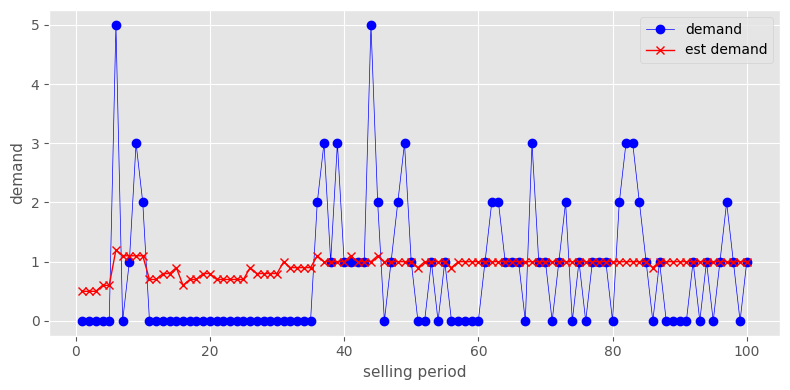

In [160]:
dfe = df_test[df_test.unique_selling_season_key==df_test.unique_selling_season_key.min()]

fig, ax = plt.subplots(figsize=(8,4))

ax.plot(dfe['selling_period'], dfe['demand'], color='b', 
        linestyle='-', marker='o', linewidth=0.5, markersize=6, label='demand')

ax.plot(dfe['selling_period'], dfe['est_demand'], color='r', 
        linestyle='-', marker='x', linewidth=1, markersize=6, label='est demand')

ax.legend( loc=0)

ax.set_xlabel('selling period', size=11)
ax.set_ylabel("demand" , size=11)

ax.grid(True)
fig.tight_layout()

plt.show()

# -----
# (3) XGBoost

### filter data setup for similar demand model, as above

In [161]:
# filter for interesting competitions
df_select = df_comp_details[df_comp_details.competition_id.isin(interesting_competitions)]

In [162]:
df_select['demand_cumsum'] = df_select.groupby('unique_selling_season_key')['demand'].cumsum()

df_select = df_select[df_select.demand_cumsum<80]
df_select = df_select[df_select.competitor_has_capacity==True]

df_select.head()

,competition_id,selling_season,selling_period,competitor_id,price_competitor,price,demand,competitor_has_capacity,calculation_duration,errors,selling_price,revenue,unique_selling_season_key,demand_cumsum
0,34KdGK,1,1,SuperGoshawk,24.5,54.8,0,True,0.014,0.0,NaN,0.0,34KdGK_1,0
1,34KdGK,1,2,SuperGoshawk,27.0,54.8,0,True,0.013,0.0,NaN,0.0,34KdGK_1,0
2,34KdGK,1,3,SuperGoshawk,29.7,54.8,0,True,0.012,0.0,NaN,0.0,34KdGK_1,0
3,34KdGK,1,4,SuperGoshawk,32.7,54.8,0,True,0.010,0.0,NaN,0.0,34KdGK_1,0
4,34KdGK,1,5,SuperGoshawk,35.9,54.8,0,True,0.008,0.0,NaN,0.0,34KdGK_1,0


## Feature engineering - Be Creative!

In [163]:
# rolling mean on my price
df_select['rolling_avg_price_season'] = (
    df_select.groupby(['selling_season', 'competitor_id'])['price']
    .expanding()
    .mean()
    .reset_index(level=[0, 1], drop=True)
)
# rolling mean on my selling price
df_select['rolling_avg_selling_price_season'] = (
    df_select.groupby(['selling_season', 'competitor_id'])['selling_price']
    .expanding()
    .mean()
    .reset_index(level=[0, 1], drop=True)
)
# rolling mean on my competitor price
df_select['rolling_avg_price_competitor_season'] = (
    df_select.groupby(['selling_season', 'competitor_id'])['price_competitor']
    .expanding()
    .mean()
    .reset_index(level=[0, 1], drop=True)
)
# rolling sum of my demand
df_select['rolling_sum_demand_season'] = (
    df_select.groupby(['selling_season', 'competitor_id'])['demand']
    .expanding()
    .sum()
    .reset_index(level=[0, 1], drop=True)
)

grp_cols = ['competition_id', 'competitor_id', 'selling_season']
# --- New Features ---

# 1. Relative Price Metrics
df_select['price_diff_competitor'] = df_select['price'] - df_select['price_competitor']
df_select['price_ratio_competitor'] = df_select['price'] / df_select['price_competitor']

# 2. Revenue Metrics
df_select['revenue'] = df_select['price'] * df_select['demand']
df_select['cumulative_revenue_season'] = (
    df_select.groupby(grp_cols)['revenue']
    .expanding()
    .sum()
    .reset_index(level=[0, 1, 2], drop=True)
)

# 3. Lagged Features (Shifted by 1 period)
# Using groupby to prevent shifting data from the previous season into the current one
df_select['lag_price_1'] = df_select.groupby(grp_cols)['price'].shift(1)
df_select['lag_price_competitor_1'] = df_select.groupby(grp_cols)['price_competitor'].shift(1)
df_select['lag_demand_1'] = df_select.groupby(grp_cols)['demand'].shift(1)

# 4. Trend Features (Difference from previous period)
df_select['diff_price_1'] = df_select['price'] - df_select['lag_price_1']
df_select['diff_price_competitor_1'] = df_select['price_competitor'] - df_select['lag_price_competitor_1']

# 5. Volatility (Standard Deviation of price)
df_select['rolling_std_price_season'] = (
    df_select.groupby(grp_cols)['price']
    .expanding()
    .std()
    .reset_index(level=[0, 1, 2], drop=True)
)

In [164]:
print(df_select.columns)
cols = [ 'competitor_has_capacity',
       'selling_period', 'price', 'demand', 
       'rolling_avg_price_season',
       'rolling_avg_selling_price_season',
       'rolling_avg_price_competitor_season', 
       'rolling_sum_demand_season',
       'price_diff_competitor', 
       'price_ratio_competitor',
       'cumulative_revenue_season', 
       'lag_price_1', 
       'lag_price_competitor_1',
       'lag_demand_1', 
       'diff_price_1', 
       'diff_price_competitor_1',]

Index(['competition_id', 'selling_season', 'selling_period', 'competitor_id',
       'price_competitor', 'price', 'demand', 'competitor_has_capacity',
       'calculation_duration', 'errors', 'selling_price', 'revenue',
       'unique_selling_season_key', 'demand_cumsum',
       'rolling_avg_price_season', 'rolling_avg_selling_price_season',
       'rolling_avg_price_competitor_season', 'rolling_sum_demand_season',
       'price_diff_competitor', 'price_ratio_competitor',
       'cumulative_revenue_season', 'lag_price_1', 'lag_price_competitor_1',
       'lag_demand_1', 'diff_price_1', 'diff_price_competitor_1',
       'rolling_std_price_season'],
      dtype='object')


In [165]:
df_select[cols].head(10)

,competitor_has_capacity,selling_period,price,demand,rolling_avg_price_season,rolling_avg_selling_price_season,rolling_avg_price_competitor_season,rolling_sum_demand_season,price_diff_competitor,price_ratio_competitor,cumulative_revenue_season,lag_price_1,lag_price_competitor_1,lag_demand_1,diff_price_1,diff_price_competitor_1
0,True,1,54.8,0,54.800000,NaN,24.500000,0.0,30.3,2.236735,0.0,NaN,NaN,NaN,NaN,NaN
1,True,2,54.8,0,54.800000,NaN,25.750000,0.0,27.8,2.029630,0.0,54.8,24.5,0.0,0.0,2.5
2,True,3,54.8,0,54.800000,NaN,27.066667,0.0,25.1,1.845118,0.0,54.8,27.0,0.0,0.0,2.7
3,True,4,54.8,0,54.800000,NaN,28.475000,0.0,22.1,1.675841,0.0,54.8,29.7,0.0,0.0,3.0
4,True,5,54.8,0,54.800000,NaN,29.960000,0.0,18.9,1.526462,0.0,54.8,32.7,0.0,0.0,3.2
5,True,6,27.4,5,50.233333,27.4,31.550000,5.0,-12.1,0.693671,137.0,54.8,35.9,0.0,-27.4,3.6
6,True,7,27.4,0,46.971429,27.4,30.957143,5.0,0.0,1.000000,137.0,27.4,39.5,5.0,0.0,-12.1
7,True,8,27.4,1,44.525000,27.4,30.637500,6.0,-1.0,0.964789,164.4,27.4,27.4,0.0,0.0,1.0
8,True,9,27.4,0,42.622222,27.4,30.277778,6.0,0.0,1.000000,164.4,27.4,28.4,1.0,0.0,-1.0
9,True,10,27.4,2,41.100000,27.4,30.090000,8.0,-1.0,0.964789,219.2,27.4,27.4,0.0,0.0,1.0


#### generate test & train

In [166]:
df_select_xgb = df_select[df_select['demand'].notnull()]
trainseasons_80, testseasons_20 = train_test_split(df_select_xgb.unique_selling_season_key.unique(), test_size=0.2, random_state=42)

df_train = df_select_xgb[df_select_xgb.unique_selling_season_key.isin(trainseasons_80)]
df_test = df_select_xgb[df_select_xgb.unique_selling_season_key.isin(testseasons_20)]

In [167]:
# split data for evaluation
initial_features = [ 'price',
       'selling_period',    
       'rolling_avg_price_season',
       'rolling_avg_selling_price_season',
       'rolling_avg_price_competitor_season', 
       'rolling_sum_demand_season',
       'rolling_std_price_season']
col_usable = ['competitor_has_capacity',
       'selling_period', 
       'price', 
       'rolling_avg_price_competitor_season', 
       'rolling_sum_demand_season',
       'lag_price_competitor_1',
       'price_competitor',
       'price_ratio_competitor',
       'cumulative_revenue_season', 
       # 'rolling_avg_price_season',
       # 'rolling_avg_selling_price_season',
       # 'lag_price_1', 
       # 'price_diff_competitor',        
       # 'lag_demand_1', 
       # 'diff_price_1', 
       # 'diff_price_competitor_1'
       ]
X_train = df_train[col_usable]
X_test = df_test[col_usable]
# X_train = df_train[initial_features]
# X_test = df_test[initial_features]

y_train = df_train[['demand']]
y_test = df_test[['demand']]

### train & evaluate XGBoost

In [168]:
# model
model = xgb.XGBRegressor(
    n_estimators=10,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
model.fit(X_train, y_train)

############
# predictions
y_pred = model.predict(X_test)
# print(X_test)
# print(y_pred)
# # evaluation 
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")

importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
print(importance)

R² Score: 0.4194
                               feature  importance
7               price_ratio_competitor    0.482777
2                                price    0.229552
8            cumulative_revenue_season    0.121448
4            rolling_sum_demand_season    0.064272
1                       selling_period    0.038373
5               lag_price_competitor_1    0.024929
3  rolling_avg_price_competitor_season    0.022943
6                     price_competitor    0.015705
0              competitor_has_capacity    0.000000


In [169]:
# price_competitor,price,price_ratio_competitor,cumulative_revenue_season,competitor_has_capacity ,rolling_sum_demand_season,selling_period, rolling_avg_price_competitor_season,lag_price_competitor_1

## parameter tuning via parameter grid search

In [170]:
# Define parameter grid
param_grid = {
    'n_estimators': [30, 50, 75, 100],
    'max_depth': [3, 5, 7],
    'learning_rate': [0000.2, 0.1, 0.07],
}

# GridSearchCV (exhaustive, slower)
model = xgb.XGBRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=6,
    scoring='r2',
    n_jobs=1,
    verbose=3
)
grid_search.fit(X_train, y_train)

# Best results
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV R² Score: {grid_search.best_score_:.4f}")

# Evaluate on test set
# predictions
y_pred = grid_search.best_estimator_.predict(X_test)

# evaluation 
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")

importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': grid_search.best_estimator_.feature_importances_
}).sort_values('importance', ascending=False)
print(importance)

Fitting 6 folds for each of 36 candidates, totalling 216 fits
[CV 1/6] END learning_rate=0.2, max_depth=3, n_estimators=30;, score=0.460 total time=   0.0s
[CV 2/6] END learning_rate=0.2, max_depth=3, n_estimators=30;, score=0.331 total time=   0.0s
[CV 3/6] END learning_rate=0.2, max_depth=3, n_estimators=30;, score=0.486 total time=   0.0s
[CV 4/6] END learning_rate=0.2, max_depth=3, n_estimators=30;, score=0.501 total time=   0.0s
[CV 5/6] END learning_rate=0.2, max_depth=3, n_estimators=30;, score=0.261 total time=   0.0s
[CV 6/6] END learning_rate=0.2, max_depth=3, n_estimators=30;, score=0.361 total time=   0.0s
[CV 1/6] END learning_rate=0.2, max_depth=3, n_estimators=50;, score=0.485 total time=   0.0s
[CV 2/6] END learning_rate=0.2, max_depth=3, n_estimators=50;, score=0.363 total time=   0.0s
[CV 3/6] END learning_rate=0.2, max_depth=3, n_estimators=50;, score=0.504 total time=   0.0s
[CV 4/6] END learning_rate=0.2, max_depth=3, n_estimators=50;, score=0.511 total time=   0.0

In [171]:
model = grid_search.best_estimator_


lig = X_test[2:3]
print(lig)
print('A'*50)
pred_demand = model.predict(lig)
demand = y_test[0:1]
print(pred_demand)
print(demand)

      competitor_has_capacity  selling_period  price  \
1002                     True               3   47.8   

      rolling_avg_price_competitor_season  rolling_sum_demand_season  \
1002                            25.366667                        0.0   

      lag_price_competitor_1  price_competitor  price_ratio_competitor  \
1002                    25.3              27.8                1.719424   

      cumulative_revenue_season  
1002                        0.0  
AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA
[-0.19648983]
      demand
1000       0


In [172]:
import pickle

# On sauvergarde le modèle actuel
with open('xgb_demand_model.pkl', "wb") as f:
    pickle.dump(model, f, protocol=pickle.HIGHEST_PROTOCOL)
# load from pickle
with open('xgb_demand_model.pkl', 'rb') as f:
    model = pickle.load(f)


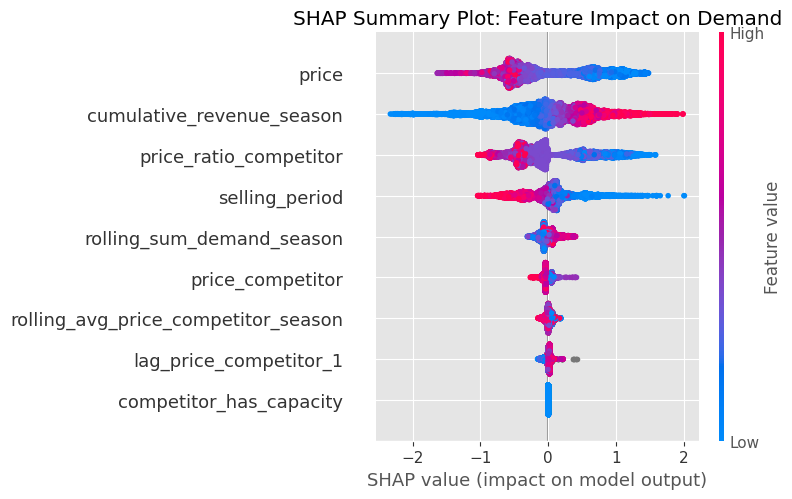

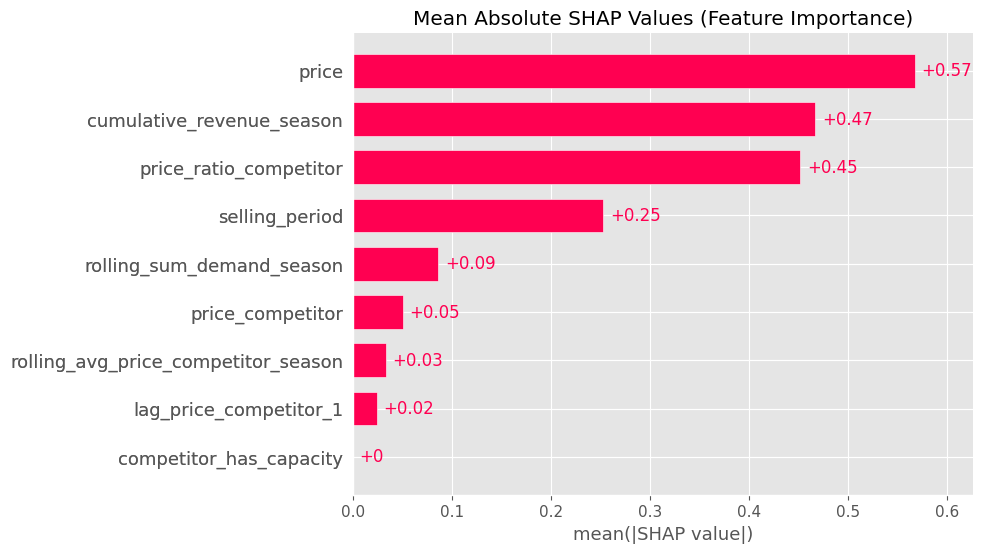

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

<Figure size 800x600 with 0 Axes>

In [173]:
import shap

# 4. SHAP Analysis
# Initialize the explainer
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# --- Plot 1: Summary Plot (Global Feature Impact) ---
# This shows how high/low values of a feature impact the output (positive/negative)
plt.figure(figsize=(10, 8))
plt.title("SHAP Summary Plot: Feature Impact on Demand")
shap.summary_plot(shap_values, X_test, show=False)
plt.show()

# --- Plot 2: Bar Plot (Average Magnitude of Impact) ---
plt.figure(figsize=(10, 8))
plt.title("Mean Absolute SHAP Values (Feature Importance)")
shap.plots.bar(shap_values, show=False)
plt.show()

# --- Plot 3: Dependence Plot (Deep dive into top feature) ---
# Finds the most important feature and plots its specific effect
top_feature = X_test.columns[importances.argmax()] if 'importances' in locals() else 'lag_demand_1'
# Or just pick the one from the summary plot, e.g., 'lag_demand_1'
plt.figure(figsize=(8, 6))
shap.plots.scatter(shap_values[:, top_feature], color=shap_values)
plt.title(f"SHAP Dependence Plot for {top_feature}")
plt.show()

## -----
## (4) EXTRA Points to consider

- Special handling when competitor is out of stock
- How to predict the next competitor price
